In [2]:
import numpy as np
from sim_library.simulation import simulate_alg_cooling, simulate_alg_cooling_custom
from sim_library.sequences import RR3_gate, RR3short_gate, exchange10_gate, PulseSequence, DownPulse,  gen_MDFEup_seq, FreeEvolution
from sim_library.sequences2 import RR3short_gate as RR3short_gate2
from sim_library.sequences2 import exchange10_gate as exchange10_gate2
from sim_library.data_io import load_p_dists
from sim_library.plotting import plot_coolingcycles_23, plot_coolingcycles_22, plot_coolingcycles_21, fit_gaussian
from sim_library.constants import k_eff, dR, m, omega_eg, kb
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path

In [8]:
k = k_eff
print( ((8/2)*hbar*k/m)**2*m/kb)

2.3554673698299985e-05


In [3]:


N = 50000

Temp = 5.93e-6

rng = np.random.default_rng()
rng_state = dict(rng.bit_generator.state)
sigma = np.sqrt(kb*Temp/m)
p_dist = (m*rng.normal(loc = 0, scale = sigma, size = N)) + (0.5*hbar*k_eff)

cycles = 16

rabi_freq = 2*pi*1e10
rabi_time = 2*pi/rabi_freq

time_steps = 1

RR3 = RR3short_gate(rabi_freq=rabi_freq, time_steps=time_steps)
RR3.build_seq()

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[19] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

beam_profile = np.full(N, 1)
# beam_profile = np.random.uniform(0.9, 1.1, N)
# beam_profile = np.random.normal(loc=1.0, scale=0.0167, size=N)

moms_list, fracs_list = simulate_alg_cooling_custom(basis=basis, sequence=RR3, p_dist=p_dist, initial_state=initial_state, beam_profile=beam_profile, cycles=cycles, rabi_freq=rabi_freq, pumping_route='f3',
                                                    #    alternating=True,
                                                        save_dir='data/algorithmic cooling',
                                                        )

In [4]:


N = 50000

Temp = 5.93e-6

rng = np.random.default_rng()
rng_state = dict(rng.bit_generator.state)
sigma = np.sqrt(kb*Temp/m)
p_dist = (m*rng.normal(loc = 0, scale = sigma, size = N)) + (0.5*hbar*k_eff)

cycles = 16

rabi_freq = 2*pi*1e10
rabi_time = 2*pi/rabi_freq

time_steps = 1

RR3 = RR3short_gate(rabi_freq=rabi_freq, time_steps=time_steps)
RR3.build_seq()

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[20] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

beam_profile = np.full(N, 1)
# beam_profile = np.random.uniform(0.9, 1.1, N)
# beam_profile = np.random.normal(loc=1.0, scale=0.0167, size=N)

moms_list, fracs_list = simulate_alg_cooling_custom(basis=basis, sequence=RR3, p_dist=p_dist, initial_state=initial_state, beam_profile=beam_profile, cycles=cycles, rabi_freq=rabi_freq, pumping_route='f3',
                                                    #    alternating=True,
                                                        save_dir='data/algorithmic cooling',
                                                        )

In [11]:
path = Path("data/algorithmic cooling/2026-06-09_algcooling_f3_16cycles_50000atoms_1e+10Hz.h5")
loaded_dict = load_p_dists(file_path=path)
moms_list = loaded_dict["p_list"]
fracs_list = loaded_dict["weights_list"]
basis = loaded_dict["basis"]
Temp = loaded_dict["init_temp"]

In [12]:
moms_list = [mom / (hbar * k_eff) for mom in moms_list]

In [13]:
global_min = min([min(m) for m in moms_list])
global_max = max([max(m) for m in moms_list])
global_range = (global_min, global_max)

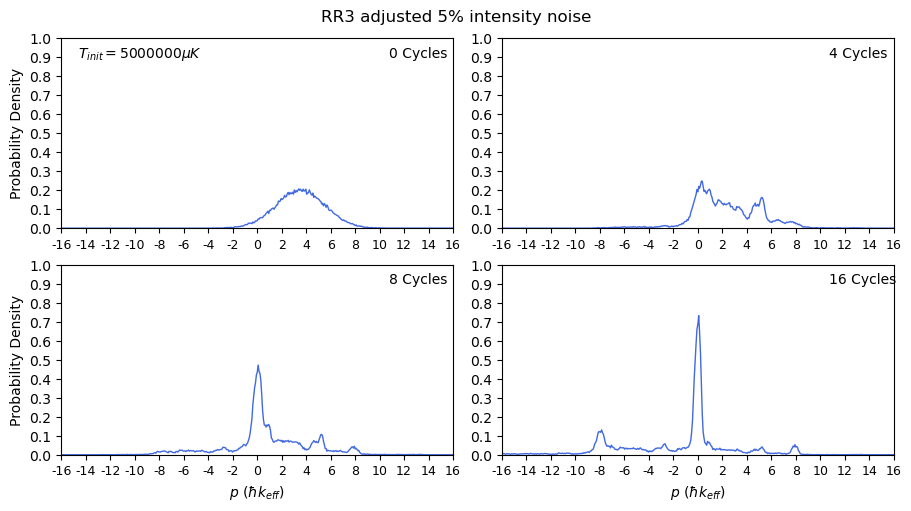

In [14]:

cycles_list = np.array([0,4,8,16])
index_list = np.array([0,8,16,32])
bins_list = np.full(4, 1000)
bins_list[0] = 1000

plot_coolingcycles_22(moms_list=moms_list, fracs_list=fracs_list, basis=basis, datarange=global_range, cycles_list=cycles_list, index_list=index_list, bins_list=bins_list, title='RR3 adjusted 5% intensity noise', temp=5, show=False,
                      ylims=1,
                     #   save_dir="plots/histograms/RR2/2026-03-20_RR2_adjustedMDFE_0.05beam_f3_96cycles_15muK_6000atoms_1e6Hz.png"
                       )

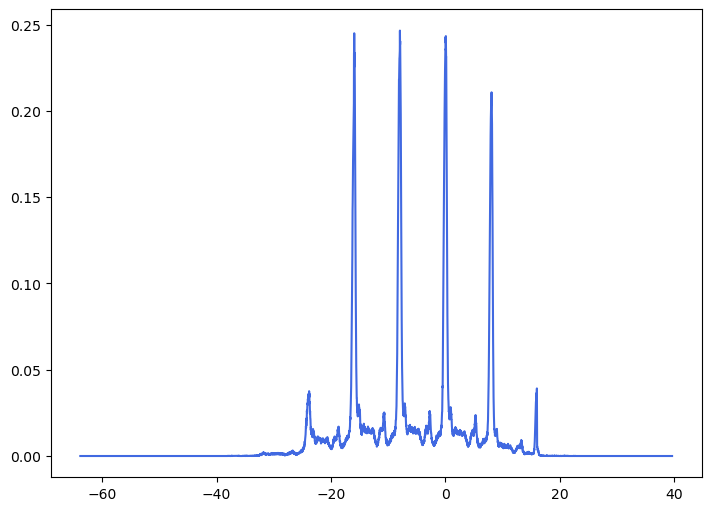

In [7]:


plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(1,1, figsize=(7, 5), layout= 'constrained')

counts, bin_edges = np.histogram(moms_list[-1], weights=fracs_list[-1], bins = 5000, density=True, range=global_range)
bindiff = bin_edges[1]-bin_edges[0]
binmids = bin_edges[:-1] + (bindiff/2)
ax.plot(binmids, counts, linewidth=1.5, c = 'royalblue')

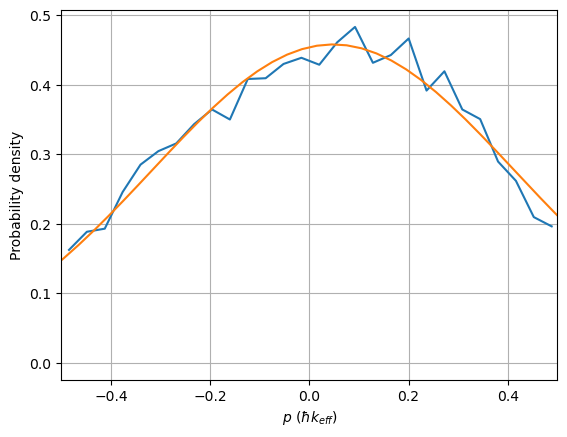

Efficiency: 41.8213%
Temperature: 0.196511muK
Center: 0.0479649hbark


In [17]:
amp, T, shift, _ = fit_gaussian(moms_list[-17], fracs=fracs_list[-17], range = global_range, lowlim=-0.5, highlim=0.5, nbins=2000, plot=True)

print(f'Efficiency: {amp*100:.6g}%')
print(f'Temperature: {T*1e6:.6g}muK')
print(rf'Center: {shift:.6g}hbark')

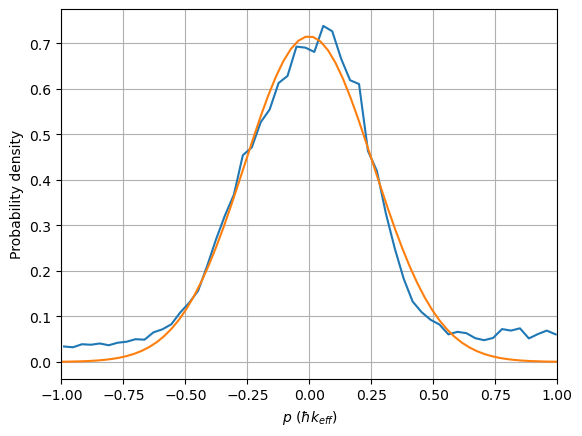

Efficiency: 46.488%
Temperature: 0.0996454muK
Center: -0.00167828hbark


In [18]:
amp, T, shift, _ = fit_gaussian(moms_list[-1], fracs=fracs_list[-1], range = global_range, lowlim=-1, highlim=1, nbins=2000, plot=True)

print(f'Efficiency: {amp*100:.6g}%')
print(f'Temperature: {T*1e6:.6g}muK')
print(rf'Center: {shift:.6g}hbark')

In [ ]:
basis = np.array([-1,0,1])
init_mom_dist = np.array([1,2,3,4,5,6,7,8])

mom_dist_grid = init_mom_dist[np.newaxis, :] + (hbar * k_eff * basis[:, np.newaxis])
print(mom_dist_grid)

[[0 1 2 3 4 5 6 7]
 [1 2 3 4 5 6 7 8]
 [2 3 4 5 6 7 8 9]]
